# Hybrid LSTM-SGARCH (Daily Target, Walk-Forward)

This notebook builds a **hybrid model** for Bitcoin log-return forecasting with a **daily target variable**.

Target definition:

```text
r_t = log(P_t / P_{t-1})
```

where `P_t` is the Bitcoin daily close price.

Motivation:

- Bitcoin is highly volatile, nonlinear, and shows volatility clustering.
- **LSTM** is used to model the conditional mean (next daily return).
- **SGARCH(1,1)** is fit on LSTM residuals to model conditional volatility.
- The hybrid design is intended to improve both point forecasts and volatility-aware decisions.

Pipeline:

- TensorFlow many-to-one LSTM with TensorBoard logging.
- Chronological split: **train / validation / test**.
- Walk-forward validation with **rolling 30-day training window**.
- Grid search with ~50 LSTM combinations.
- Best model checkpointing and live result persistence.

## Notes

- This notebook is WSL/GPU-first. Use kernel: `Python (LSTM WSL GPU)`.
- Target variable follows the daily return definition `r_t = log(P_t / P_{t-1})`.
- LSTM predicts the next daily return, SGARCH(1,1) models residual volatility.
- Best model checkpoints are saved during grid search, so interruption does not lose best weights.
- TensorBoard logs are stored in `artifacts/lstm_sgarch_walk_forward/tensorboard/`.
- TensorBoard is auto-started when training begins if the environment is healthy.
- If TensorBoard is disabled because of `pkg_resources` errors, run:

```bash
uv sync --group dev --group linux-gpu
```

In [ ]:
from __future__ import annotations

import atexit
import importlib.util
import json
import random
import shutil
import socket
import subprocess
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

print("TensorFlow:", tf.__version__)

I0000 00:00:1780246533.123539 1648960 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780246533.594284 1648960 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780246545.508847 1648960 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


In [ ]:
# Core configuration
DATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_5min.csv")
ARTIFACTS_DIR = Path("artifacts/lstm_sgarch_walk_forward")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = "timestamp_utc"
TARGET_COL = "target_next_daily_log_return"
FEATURE_COLS = ["daily_log_return", "daily_volatility", "volatility_7d"]

TRAIN_WINDOW_DAYS = 30
VAL_PERIOD_DAYS = 30
TEST_PERIOD_DAYS = 30
FOLD_STEP_DAYS = 3
FOLD_HORIZON_DAYS = 3

MAX_EPOCHS = 25
PATIENCE = 4
GRID_LIMIT = 50
SEED = 42

USE_CUDA_IF_AVAILABLE = True
REQUIRE_CUDA = True
ENABLE_XLA = True
ENABLE_MIXED_PRECISION = True

SGARCH_P = 1
SGARCH_Q = 1
SGARCH_SCALE = 100.0

AUTO_START_TENSORBOARD = True
TENSORBOARD_HOST = "127.0.0.1"
TENSORBOARD_PORT = 6006
TENSORBOARD_LOGDIR = ARTIFACTS_DIR / "tensorboard"
TENSORBOARD_LOGDIR.mkdir(parents=True, exist_ok=True)
TENSORBOARD_PROCESS: subprocess.Popen | None = None
TENSORBOARD_STATUS_PRINTED = False
TENSORBOARD_WARNING_EMITTED = False

In [ ]:
def probe_tensorboard() -> tuple[bool, str | None]:
    try:
        import pkg_resources  # noqa: F401
        import tensorboard.main  # noqa: F401

        return True, None
    except Exception as exc:
        return False, str(exc)


HAS_TENSORBOARD, TENSORBOARD_ERROR = probe_tensorboard()
if not HAS_TENSORBOARD:
    AUTO_START_TENSORBOARD = False
    print("TensorBoard disabled:", TENSORBOARD_ERROR)
    print("Install or repair with: uv sync --group dev --group linux-gpu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def configure_runtime_for_speed(
    use_cuda_if_available: bool = USE_CUDA_IF_AVAILABLE,
    require_cuda: bool = REQUIRE_CUDA,
    enable_xla: bool = ENABLE_XLA,
    enable_mixed_precision: bool = ENABLE_MIXED_PRECISION,
) -> list[tf.config.PhysicalDevice]:
    if enable_xla:
        tf.config.optimizer.set_jit(True)

    gpus = tf.config.list_physical_devices("GPU")

    if use_cuda_if_available and gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        if enable_mixed_precision:
            tf.keras.mixed_precision.set_global_policy("mixed_float16")
    else:
        tf.keras.mixed_precision.set_global_policy("float32")

    if require_cuda and not gpus:
        raise RuntimeError(
            "CUDA GPU was required but not detected. "
            "Launch from WSL with: bash scripts/wsl_jupyter.sh and use kernel Python (LSTM WSL GPU)."
        )

    print("Detected GPUs:", gpus)
    print("XLA enabled:", enable_xla)
    print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())
    print("TensorBoard available:", HAS_TENSORBOARD)
    return gpus


In [ ]:
set_seed(SEED)
GPUS = configure_runtime_for_speed()

/tmp/ipykernel_1648960/2337226583.py:42: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: F401


Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA enabled: True
Mixed precision policy: <DTypePolicy "mixed_float16">
TensorBoard available: True


In [ ]:
# Data load and daily target engineering
raw = pd.read_csv(DATA_PATH)
raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
raw = raw.sort_values(TIMESTAMP_COL).reset_index(drop=True)

raw["log_close_5m"] = np.log(raw["close"])
raw["log_return_5m"] = raw["log_close_5m"].diff()

daily = raw.set_index(TIMESTAMP_COL).resample("1D").agg(close=("close", "last"))
daily_intraday_vol = (
    raw.set_index(TIMESTAMP_COL)["log_return_5m"]
    .resample("1D")
    .std()
    .rename("daily_volatility")
)

daily = daily.join(daily_intraday_vol)

daily["daily_log_return"] = np.log(daily["close"] / daily["close"].shift(1))
daily["volatility_7d"] = daily["daily_volatility"].rolling(7).mean()
daily[TARGET_COL] = daily["daily_log_return"].shift(-1)

df = (
    daily.reset_index()[[TIMESTAMP_COL, *FEATURE_COLS, TARGET_COL]]
    .dropna()
    .reset_index(drop=True)
)

max_time = df[TIMESTAMP_COL].max()
test_start = max_time - pd.Timedelta(days=TEST_PERIOD_DAYS)
val_start = test_start - pd.Timedelta(days=VAL_PERIOD_DAYS)

split_masks = {
    "train": df[TIMESTAMP_COL] < val_start,
    "validation": (df[TIMESTAMP_COL] >= val_start) & (df[TIMESTAMP_COL] < test_start),
    "test": df[TIMESTAMP_COL] >= test_start,
}

split_summary = pd.DataFrame(
    {
        name: {
            "rows": int(mask.sum()),
            "start": df.loc[mask, TIMESTAMP_COL].min(),
            "end": df.loc[mask, TIMESTAMP_COL].max(),
        }
        for name, mask in split_masks.items()
    }
).T

In [ ]:
print("Prepared daily rows:", len(df))
print("Target:", "r_t = log(P_t / P_{t-1}), predicted one day ahead via shift(-1)")
print("Validation starts:", val_start)
print("Test starts:", test_start)
display(split_summary)

Prepared daily rows: 3646
Target: r_t = log(P_t / P_{t-1}), predicted one day ahead via shift(-1)
Validation starts: 2026-02-11 00:00:00+00:00
Test starts: 2026-03-13 00:00:00+00:00


,rows,start,end
train,3585,2016-04-19 00:00:00+00:00,2026-02-10 00:00:00+00:00
validation,30,2026-02-11 00:00:00+00:00,2026-03-12 00:00:00+00:00
test,31,2026-03-13 00:00:00+00:00,2026-04-12 00:00:00+00:00


In [ ]:
def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int) -> tuple[np.ndarray, np.ndarray]:
    x_list: list[np.ndarray] = []
    y_list: list[float] = []

    for idx in range(seq_len, len(features)):
        x_list.append(features[idx - seq_len:idx])
        y_list.append(targets[idx])

    if not x_list:
        return (
            np.empty((0, seq_len, features.shape[1]), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
        )

    return np.asarray(x_list, dtype=np.float32), np.asarray(y_list, dtype=np.float32)


def build_walk_forward_folds(
    data: pd.DataFrame,
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    train_window_days: int,
    step_days: int,
    horizon_days: int,
) -> list[dict]:
    folds: list[dict] = []
    fold_id = 0
    cursor = start_time

    while cursor < end_time:
        eval_start = cursor
        eval_end = min(eval_start + pd.Timedelta(days=horizon_days), end_time)
        train_end = eval_start
        train_start = train_end - pd.Timedelta(days=train_window_days)

        train_rows = data[(data[TIMESTAMP_COL] >= train_start) & (data[TIMESTAMP_COL] < train_end)]
        eval_rows = data[(data[TIMESTAMP_COL] >= eval_start) & (data[TIMESTAMP_COL] < eval_end)]

        if len(train_rows) > 0 and len(eval_rows) > 0:
            folds.append(
                {
                    'fold_id': fold_id,
                    'train_start': train_start,
                    'train_end': train_end,
                    'eval_start': eval_start,
                    'eval_end': eval_end,
                }
            )
            fold_id += 1

        cursor = cursor + pd.Timedelta(days=step_days)

    return folds


def describe_folds(name: str, folds: list[dict]) -> None:
    fold_df = pd.DataFrame(folds)
    print(f'{name} folds: {len(folds)}')
    if not fold_df.empty:
        display(fold_df.head())


val_folds = build_walk_forward_folds(
    data=df,
    start_time=val_start,
    end_time=test_start,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=FOLD_STEP_DAYS,
    horizon_days=FOLD_HORIZON_DAYS,
)

test_folds = build_walk_forward_folds(
    data=df,
    start_time=test_start,
    end_time=max_time,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=FOLD_STEP_DAYS,
    horizon_days=FOLD_HORIZON_DAYS,
)

describe_folds("Validation", val_folds)
describe_folds("Test", test_folds)

Validation folds: 10


,fold_id,train_start,train_end,eval_start,eval_end
0,0,2026-01-12 00:00:00+00:00,2026-02-11 00:00:00+00:00,2026-02-11 00:00:00+00:00,2026-02-14 00:00:00+00:00
1,1,2026-01-15 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00
2,2,2026-01-18 00:00:00+00:00,2026-02-17 00:00:00+00:00,2026-02-17 00:00:00+00:00,2026-02-20 00:00:00+00:00
3,3,2026-01-21 00:00:00+00:00,2026-02-20 00:00:00+00:00,2026-02-20 00:00:00+00:00,2026-02-23 00:00:00+00:00
4,4,2026-01-24 00:00:00+00:00,2026-02-23 00:00:00+00:00,2026-02-23 00:00:00+00:00,2026-02-26 00:00:00+00:00


Test folds: 10


,fold_id,train_start,train_end,eval_start,eval_end
0,0,2026-02-11 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-16 00:00:00+00:00
1,1,2026-02-14 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-19 00:00:00+00:00
2,2,2026-02-17 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-22 00:00:00+00:00
3,3,2026-02-20 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-25 00:00:00+00:00
4,4,2026-02-23 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-28 00:00:00+00:00


In [ ]:
def build_lstm_model(
    seq_len: int,
    n_features: int,
    lstm_units: int,
    dropout: float,
    learning_rate: float,
) -> tf.keras.Model:
    layers: list[tf.keras.layers.Layer] = [
        tf.keras.layers.Input(shape=(seq_len, n_features)),
        tf.keras.layers.LSTM(lstm_units, recurrent_dropout=0.0),
    ]

    if dropout > 0.0:
        layers.append(tf.keras.layers.Dropout(dropout))

    layers.extend(
        [
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(1, dtype='float32'),
        ]
    )

    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model


def prepare_fold_data(data: pd.DataFrame, fold: dict, seq_len: int) -> dict | None:
    train_df = data[(data[TIMESTAMP_COL] >= fold['train_start']) & (data[TIMESTAMP_COL] < fold['train_end'])].copy()
    eval_df = data[(data[TIMESTAMP_COL] >= fold['eval_start']) & (data[TIMESTAMP_COL] < fold['eval_end'])].copy()

    if len(train_df) <= seq_len + 10 or len(eval_df) == 0:
        return None

    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_df[FEATURE_COLS])
    eval_features = scaler.transform(eval_df[FEATURE_COLS])

    train_targets = train_df[TARGET_COL].to_numpy(dtype=np.float32)
    eval_targets = eval_df[TARGET_COL].to_numpy(dtype=np.float32)

    x_all, y_all = make_sequences(train_features, train_targets, seq_len)
    if len(x_all) < 12:
        return None

    split_idx = int(len(x_all) * 0.8)
    if split_idx <= 0 or split_idx >= len(x_all):
        return None

    x_train = x_all[:split_idx]
    y_train = y_all[:split_idx]
    x_val = x_all[split_idx:]
    y_val = y_all[split_idx:]

    combined_features = np.vstack([train_features, eval_features])
    combined_targets = np.concatenate([train_targets, eval_targets])

    x_eval_list: list[np.ndarray] = []
    y_eval_list: list[float] = []

    eval_start_idx = len(train_df)
    for idx in range(eval_start_idx, len(combined_features)):
        start = idx - seq_len
        if start < 0:
            continue
        x_eval_list.append(combined_features[start:idx])
        y_eval_list.append(float(combined_targets[idx]))

    if not x_eval_list:
        return None

    x_eval = np.asarray(x_eval_list, dtype=np.float32)
    y_eval = np.asarray(y_eval_list, dtype=np.float32)

    return {
        'x_all_train_window': x_all,
        'y_all_train_window': y_all,
        'x_train': x_train,
        'y_train': y_train,
        'x_val': x_val,
        'y_val': y_val,
        'x_eval': x_eval,
        'y_eval': y_eval,
        'eval_timestamps': eval_df[TIMESTAMP_COL].to_numpy(),
    }


def is_port_open(host: str, port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.2)
        return sock.connect_ex((host, port)) == 0


def ensure_tensorboard_running(log_dir: Path) -> str | None:
    global TENSORBOARD_PROCESS, TENSORBOARD_STATUS_PRINTED, AUTO_START_TENSORBOARD

    if not HAS_TENSORBOARD or not AUTO_START_TENSORBOARD:
        return None

    log_dir.mkdir(parents=True, exist_ok=True)
    url = f'http://{TENSORBOARD_HOST}:{TENSORBOARD_PORT}'

    if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
        if not TENSORBOARD_STATUS_PRINTED:
            print(f'TensorBoard already running: {url}')
            TENSORBOARD_STATUS_PRINTED = True
        return url

    if TENSORBOARD_PROCESS is not None and TENSORBOARD_PROCESS.poll() is not None:
        TENSORBOARD_PROCESS = None

    if TENSORBOARD_PROCESS is None:
        launch_log = ARTIFACTS_DIR / 'tensorboard_launch.log'
        cmd = [
            sys.executable,
            '-m',
            'tensorboard.main',
            '--logdir',
            str(log_dir),
            '--host',
            TENSORBOARD_HOST,
            '--port',
            str(TENSORBOARD_PORT),
            '--reload_interval',
            '5',
        ]
        with launch_log.open('ab') as log_file:
            TENSORBOARD_PROCESS = subprocess.Popen(
                cmd,
                stdout=subprocess.DEVNULL,
                stderr=log_file,
            )

    for _ in range(20):
        if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
            if not TENSORBOARD_STATUS_PRINTED:
                print(f'TensorBoard started: {url} (logdir={log_dir})')
                TENSORBOARD_STATUS_PRINTED = True
            return url
        time.sleep(0.25)

    proc_exit = None if TENSORBOARD_PROCESS is None else TENSORBOARD_PROCESS.poll()
    if not TENSORBOARD_STATUS_PRINTED:
        if proc_exit is None:
            print(
                f'TensorBoard process launched but port {TENSORBOARD_PORT} is not ready yet. '
                f'Check logs: {ARTIFACTS_DIR / "tensorboard_launch.log"}'
            )
        else:
            print(
                f'TensorBoard launch failed with exit code {proc_exit}. '
                f'Check logs: {ARTIFACTS_DIR / "tensorboard_launch.log"}'
            )
            AUTO_START_TENSORBOARD = False
        TENSORBOARD_STATUS_PRINTED = True

    return url


def stop_tensorboard() -> None:
    global TENSORBOARD_PROCESS
    if TENSORBOARD_PROCESS is None:
        return

    if TENSORBOARD_PROCESS.poll() is None:
        TENSORBOARD_PROCESS.terminate()
    TENSORBOARD_PROCESS = None


atexit.register(stop_tensorboard)


def fit_sgarch_state(train_residuals: np.ndarray) -> dict:
    # Scale residuals to improve numeric stability in GARCH optimization.
    residuals_scaled = (train_residuals * SGARCH_SCALE).astype(np.float64)
    residuals_scaled = residuals_scaled[~np.isnan(residuals_scaled)]

    if len(residuals_scaled) < 50:
        base_var = float(np.var(residuals_scaled)) if len(residuals_scaled) > 1 else 1.0
        return {
            'omega': max(1e-8, 0.02 * base_var),
            'alpha': 0.05,
            'beta': 0.90,
            'last_sigma2': max(1e-8, base_var),
            'last_e2': max(1e-8, base_var),
            'fit_ok': False,
            'aic': float('nan'),
        }

    try:
        garch = arch_model(
            residuals_scaled,
            mean='Zero',
            vol='GARCH',
            p=SGARCH_P,
            q=SGARCH_Q,
            dist='normal',
            rescale=False,
        )
        garch_fit = garch.fit(disp='off')

        params = garch_fit.params
        omega = float(params.get('omega', np.var(residuals_scaled) * 0.02))
        alpha = float(params.get('alpha[1]', 0.05))
        beta = float(params.get('beta[1]', 0.90))

        if alpha + beta >= 0.999:
            beta = min(beta, 0.98)
            alpha = min(alpha, 0.95 - beta)

        cond_vol = np.asarray(garch_fit.conditional_volatility, dtype=np.float64)
        resid = np.asarray(garch_fit.resid, dtype=np.float64)

        last_sigma2 = float(max(1e-8, cond_vol[-1] ** 2))
        last_e2 = float(max(1e-8, resid[-1] ** 2))

        return {
            'omega': omega,
            'alpha': alpha,
            'beta': beta,
            'last_sigma2': last_sigma2,
            'last_e2': last_e2,
            'fit_ok': True,
            'aic': float(garch_fit.aic),
        }
    except Exception:
        base_var = float(np.var(residuals_scaled)) if len(residuals_scaled) > 1 else 1.0
        return {
            'omega': max(1e-8, 0.02 * base_var),
            'alpha': 0.05,
            'beta': 0.90,
            'last_sigma2': max(1e-8, base_var),
            'last_e2': max(1e-8, base_var),
            'fit_ok': False,
            'aic': float('nan'),
        }


def sgarch_forecast_path(state: dict, realized_residuals: np.ndarray) -> np.ndarray:
    omega = float(state['omega'])
    alpha = float(state['alpha'])
    beta = float(state['beta'])
    last_sigma2 = float(state['last_sigma2'])
    last_e2 = float(state['last_e2'])

    vol_path_scaled: list[float] = []

    for realized_resid in realized_residuals:
        sigma2_next = max(1e-10, omega + alpha * last_e2 + beta * last_sigma2)
        sigma_next = float(np.sqrt(sigma2_next))
        vol_path_scaled.append(sigma_next)

        realized_scaled = float(realized_resid * SGARCH_SCALE)
        last_e2 = max(1e-10, realized_scaled ** 2)
        last_sigma2 = sigma2_next

    return np.asarray(vol_path_scaled, dtype=np.float64) / SGARCH_SCALE


def hybrid_metrics(y_true: np.ndarray, y_mean: np.ndarray, y_vol: np.ndarray) -> dict:
    mean_rmse = float(np.sqrt(mean_squared_error(y_true, y_mean)))
    mean_mae = float(mean_absolute_error(y_true, y_mean))

    realized_var = np.square(y_true - y_mean)
    pred_var = np.clip(np.square(y_vol), 1e-12, None)

    qlike = float(np.mean(np.log(pred_var) + realized_var / pred_var))
    var_mse = float(np.mean(np.square(realized_var - pred_var)))

    direction_acc = float(np.mean(np.sign(y_true) == np.sign(y_mean)))

    return {
        'mean_rmse': mean_rmse,
        'mean_mae': mean_mae,
        'qlike': qlike,
        'var_mse': var_mse,
        'direction_acc': direction_acc,
    }


def train_one_fold(
    data: pd.DataFrame,
    fold: dict,
    params: dict,
    combo_dir: Path,
    fold_set_name: str,
) -> dict | None:
    fold_data = prepare_fold_data(data, fold, seq_len=params['seq_len'])
    if fold_data is None:
        return None

    fold_dir = combo_dir / fold_set_name / f"fold_{fold['fold_id']:03d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = fold_dir / 'best_lstm.keras'
    backup_dir = fold_dir / 'backup'
    tb_dir = TENSORBOARD_LOGDIR / fold_set_name / combo_dir.name / f"fold_{fold['fold_id']:03d}"
    tb_dir.mkdir(parents=True, exist_ok=True)

    tensorboard_url = ensure_tensorboard_running(TENSORBOARD_LOGDIR)

    model = build_lstm_model(
        seq_len=params['seq_len'],
        n_features=len(FEATURE_COLS),
        lstm_units=params['lstm_units'],
        dropout=params['dropout'],
        learning_rate=params['learning_rate'],
    )

    callbacks: list[tf.keras.callbacks.Callback] = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ),
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(backup_dir),
            delete_checkpoint=False,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ]

    global TENSORBOARD_WARNING_EMITTED
    if HAS_TENSORBOARD:
        callbacks.insert(
            2,
            tf.keras.callbacks.TensorBoard(
                log_dir=str(tb_dir),
                histogram_freq=0,
                write_graph=True,
                update_freq='epoch',
                profile_batch=0,
            ),
        )
    elif not TENSORBOARD_WARNING_EMITTED:
        print("TensorBoard callback disabled because TensorBoard is not usable in this environment.")
        TENSORBOARD_WARNING_EMITTED = True

    history = model.fit(
        fold_data['x_train'],
        fold_data['y_train'],
        validation_data=(fold_data['x_val'], fold_data['y_val']),
        epochs=MAX_EPOCHS,
        batch_size=params['batch_size'],
        shuffle=False,
        verbose=0,
        callbacks=callbacks,
    )

    best_lstm = tf.keras.models.load_model(checkpoint_path) if checkpoint_path.exists() else model

    # LSTM mean forecasts on evaluation window.
    y_mean_eval = best_lstm.predict(fold_data['x_eval'], verbose=0).reshape(-1)

    # Fit SGARCH on train-window residuals from LSTM mean model.
    y_mean_train_window = best_lstm.predict(fold_data['x_all_train_window'], verbose=0).reshape(-1)
    resid_train_window = fold_data['y_all_train_window'] - y_mean_train_window

    sgarch_state = fit_sgarch_state(resid_train_window)

    # Walk-forward volatility forecast, updating variance state with observed residuals.
    realized_eval_residuals = fold_data['y_eval'] - y_mean_eval
    y_vol_eval = sgarch_forecast_path(sgarch_state, realized_eval_residuals)

    metrics = hybrid_metrics(fold_data['y_eval'], y_mean_eval, y_vol_eval)

    pred_df = pd.DataFrame(
        {
            TIMESTAMP_COL: fold_data['eval_timestamps'],
            'y_true': fold_data['y_eval'],
            'lstm_mean_pred': y_mean_eval,
            'sgarch_vol_pred': y_vol_eval,
            'hybrid_upper_95': y_mean_eval + 1.96 * y_vol_eval,
            'hybrid_lower_95': y_mean_eval - 1.96 * y_vol_eval,
        }
    )
    pred_path = fold_dir / 'hybrid_predictions.csv'
    pred_df.to_csv(pred_path, index=False)

    sgarch_state_path = fold_dir / 'sgarch_state.json'
    with sgarch_state_path.open('w', encoding='utf-8') as f:
        json.dump(sgarch_state, f, indent=2)

    return {
        'fold_id': fold['fold_id'],
        'mean_rmse': metrics['mean_rmse'],
        'mean_mae': metrics['mean_mae'],
        'qlike': metrics['qlike'],
        'var_mse': metrics['var_mse'],
        'direction_acc': metrics['direction_acc'],
        'epochs_ran': len(history.history.get('loss', [])),
        'model_path': str(checkpoint_path),
        'predictions_path': str(pred_path),
        'sgarch_state_path': str(sgarch_state_path),
        'tensorboard_log_dir': str(tb_dir),
        'tensorboard_url': tensorboard_url,
    }


def build_grid(limit: int = GRID_LIMIT, seed: int = SEED) -> list[dict]:
    base_grid = {
        'seq_len': [3, 5, 7, 10, 14],
        'lstm_units': [16, 32],
        'dropout': [0.0, 0.2],
        'learning_rate': [1e-3, 5e-4, 2e-4],
        'batch_size': [64, 128],
    }

    combos = [
        {
            'seq_len': seq_len,
            'lstm_units': lstm_units,
            'dropout': dropout,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
        }
        for seq_len, lstm_units, dropout, learning_rate, batch_size in product(
            base_grid['seq_len'],
            base_grid['lstm_units'],
            base_grid['dropout'],
            base_grid['learning_rate'],
            base_grid['batch_size'],
        )
    ]

    rng = random.Random(seed)
    rng.shuffle(combos)
    return combos[:limit]


def run_grid_search(
    data: pd.DataFrame,
    folds: list[dict],
    grid: list[dict],
    output_dir: Path,
) -> tuple[pd.DataFrame, dict, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)

    results: list[dict] = []
    best_score = float('inf')
    best_params: dict | None = None
    best_lstm_path = output_dir / 'best_lstm_overall.keras'

    for idx, params in enumerate(grid, start=1):
        combo_name = f'combo_{idx:03d}'
        combo_dir = output_dir / combo_name
        combo_dir.mkdir(parents=True, exist_ok=True)

        fold_records: list[dict] = []
        for fold in folds:
            fold_result = train_one_fold(
                data=data,
                fold=fold,
                params=params,
                combo_dir=combo_dir,
                fold_set_name='validation',
            )
            if fold_result is not None:
                fold_records.append(fold_result)

        if not fold_records:
            combo_mean_rmse = float('inf')
            combo_qlike = float('inf')
            best_fold_model = None
        else:
            combo_mean_rmse = float(np.mean([r['mean_rmse'] for r in fold_records]))
            combo_qlike = float(np.mean([r['qlike'] for r in fold_records]))
            best_fold_model = min(fold_records, key=lambda r: r['mean_rmse'])['model_path']

        row = {
            'combo_id': combo_name,
            'val_mean_rmse': combo_mean_rmse,
            'val_qlike': combo_qlike,
            'n_folds_trained': len(fold_records),
            **params,
            'best_fold_model': best_fold_model,
        }
        results.append(row)

        pd.DataFrame(results).sort_values('val_mean_rmse').to_csv(
            output_dir / 'grid_search_results_live.csv',
            index=False,
        )

        if combo_mean_rmse < best_score and best_fold_model is not None:
            best_score = combo_mean_rmse
            best_params = params.copy()
            shutil.copy2(best_fold_model, best_lstm_path)
            with (output_dir / 'best_model_metadata.json').open('w', encoding='utf-8') as f:
                json.dump(
                    {
                        'best_combo': combo_name,
                        'best_val_mean_rmse': best_score,
                        'best_params': best_params,
                        'source_model': best_fold_model,
                    },
                    f,
                    indent=2,
                )

        print(f"[{idx:03d}/{len(grid):03d}] {combo_name} | val_mean_rmse={combo_mean_rmse:.8f} | folds={len(fold_records)}")

    results_df = pd.DataFrame(results).sort_values('val_mean_rmse').reset_index(drop=True)
    results_df.to_csv(output_dir / 'grid_search_results_final.csv', index=False)

    if best_params is None:
        raise RuntimeError('No model trained. Try smaller seq_len or fewer folds.')

    return results_df, best_params, best_lstm_path

In [ ]:
# Train hybrid model with grid search (validation folds)
tensorboard_url = ensure_tensorboard_running(TENSORBOARD_LOGDIR)
if tensorboard_url is not None:
    print("TensorBoard URL:", tensorboard_url)

val_grid = build_grid(limit=GRID_LIMIT, seed=SEED)
print("Grid combinations:", len(val_grid))

grid_dir = ARTIFACTS_DIR / 'grid_search'
results_df, best_params, best_lstm_path = run_grid_search(
    data=df,
    folds=val_folds,
    grid=val_grid,
    output_dir=grid_dir,
)

print("Best params:", best_params)
print("Best LSTM checkpoint:", best_lstm_path)
display(results_df.head(10))

TensorBoard process launched but port 6006 is not ready yet. Check logs: artifacts/lstm_sgarch_walk_forward/tensorboard_launch.log
TensorBoard URL: http://127.0.0.1:6006
Grid combinations: 50


I0000 00:00:1780246574.482855 1648960 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
E0000 00:00:1780246576.733289 1648960 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1780246576.742093 1649147 service.cc:153] XLA service 0x5c19724b87b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780246576.742127 1649147 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780246576.781410 1649148 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780246576.989363 1649148 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

I0000 00:00:1780246603.012922 1649147 dot_merger.cc:481] Merging Dots in computation: cluster_56__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780246609.361069 1649149 dot_merger.cc:481] Merging Dots in computation: cluster_74__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780246615.653495 1649149 dot_merger.cc:481] Merging Dots in computation: cluster_92__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780246621.042315 1649142 dot_merger.cc:481] Merging Dots in computation: cluster_110__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780246630.852105 1649147 dot_merger.cc:481] Merging Dots in computation: cluster_128__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:178024

[001/050] combo_001 | val_mean_rmse=0.04608526 | folds=10


I0000 00:00:1780246647.671182 1649147 dot_merger.cc:481] Merging Dots in computation: cluster_181__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780246655.213376 1649142 dot_merger.cc:481] Merging Dots in computation: cluster_199__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780246659.687156 1649139 dot_merger.cc:481] Merging Dots in computation: cluster_217__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780246667.811731 1649146 dot_merger.cc:481] Merging Dots in computation: cluster_235__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780246670.788196 1649141 dot_merger.cc:481] Merging Dots in computation: cluster_253__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:17802466

...

I0000 00:00:1780249405.271950 1649118 dot_merger.cc:481] Merging Dots in computation: cluster_8641__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249409.047637 1649122 dot_merger.cc:481] Merging Dots in computation: cluster_8659__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249412.812601 1649137 dot_merger.cc:481] Merging Dots in computation: cluster_8677__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249419.094860 1649126 dot_merger.cc:481] Merging Dots in computation: cluster_8695__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249422.488257 1649133 dot_merger.cc:481] Merging Dots in computation: cluster_8713__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:178

[049/050] combo_049 | val_mean_rmse=0.06237559 | folds=10


I0000 00:00:1780249461.062139 1649148 dot_merger.cc:481] Merging Dots in computation: cluster_8821__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249465.494774 1649143 dot_merger.cc:481] Merging Dots in computation: cluster_8839__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249471.575624 1649122 dot_merger.cc:481] Merging Dots in computation: cluster_8857__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249481.741399 1649126 dot_merger.cc:481] Merging Dots in computation: cluster_8875__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780249488.546776 1649133 dot_merger.cc:481] Merging Dots in computation: cluster_8893__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:178

[050/050] combo_050 | val_mean_rmse=0.07274076 | folds=10
Best params: {'seq_len': 7, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
Best LSTM checkpoint: artifacts/lstm_sgarch_walk_forward/grid_search/best_lstm_overall.keras


,combo_id,val_mean_rmse,val_qlike,n_folds_trained,seq_len,lstm_units,dropout,learning_rate,batch_size,best_fold_model
0,combo_035,0.030079,-5.151030,10,7,32,0.2,0.0010,64,artifacts/lstm_sgarch_walk_forward/grid_search...
1,combo_031,0.033449,-5.213272,10,3,32,0.2,0.0005,128,artifacts/lstm_sgarch_walk_forward/grid_search...
2,combo_026,0.036511,-5.218861,10,3,16,0.0,0.0010,128,artifacts/lstm_sgarch_walk_forward/grid_search...
3,combo_005,0.038393,-5.159594,10,10,32,0.2,0.0005,64,artifacts/lstm_sgarch_walk_forward/grid_search...
4,combo_040,0.038660,-5.102271,10,5,32,0.0,0.0005,64,artifacts/lstm_sgarch_walk_forward/grid_search...
5,combo_029,0.040413,-4.919876,10,5,16,0.0,0.0005,64,artifacts/lstm_sgarch_walk_forward/grid_search...
6,combo_022,0.041580,-5.009379,10,7,32,0.0,0.0010,128,artifacts/lstm_sgarch_walk_forward/grid_search...
7,combo_048,0.041779,-5.109780,10,5,32,0.0,0.0002,64,artifacts/lstm_sgarch_walk_forward/grid_search...
8,combo_045,0.042473,-5.007683,10,7,32,0.0,0.0005,128,artifacts/lstm_sgarch_walk_forward/grid_search...
9,combo_025,0.043066,-5.077176,10,3,16,0.2,0.0010,128,artifacts/lstm_sgarch_walk_forward/grid_search...


In [ ]:
def evaluate_hybrid_on_folds(
    data: pd.DataFrame,
    folds: list[dict],
    params: dict,
    output_dir: Path,
    fold_set_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)

    fold_rows: list[dict] = []
    pred_frames: list[pd.DataFrame] = []

    for fold in folds:
        result = train_one_fold(
            data=data,
            fold=fold,
            params=params,
            combo_dir=output_dir,
            fold_set_name=fold_set_name,
        )
        if result is None:
            continue

        fold_rows.append(result)
        p = pd.read_csv(result['predictions_path'])
        p['fold_id'] = result['fold_id']
        pred_frames.append(p)

    if not fold_rows:
        raise RuntimeError(f'No folds trained for {fold_set_name}')

    metrics_df = pd.DataFrame(fold_rows).sort_values('fold_id').reset_index(drop=True)
    preds_df = pd.concat(pred_frames, ignore_index=True)

    metrics_df.to_csv(output_dir / f'{fold_set_name}_fold_metrics.csv', index=False)
    preds_df.to_csv(output_dir / f'{fold_set_name}_predictions.csv', index=False)

    return metrics_df, preds_df


final_dir = ARTIFACTS_DIR / 'final_evaluation'
val_metrics_df, val_preds_df = evaluate_hybrid_on_folds(df, val_folds, best_params, final_dir, 'validation')
test_metrics_df, test_preds_df = evaluate_hybrid_on_folds(df, test_folds, best_params, final_dir, 'test')

print("Validation mean metrics:")
display(val_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_frame('value'))

print("Test mean metrics:")
display(test_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_frame('value'))

I0000 00:00:1780249518.677666 1649130 dot_merger.cc:481] Merging Dots in computation: cluster_9002__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780249522.883124 1649133 dot_merger.cc:481] Merging Dots in computation: cluster_9020__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780249526.553826 1649118 dot_merger.cc:481] Merging Dots in computation: cluster_9038__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780249530.674428 1649137 dot_merger.cc:481] Merging Dots in computation: cluster_9056__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780249534.193817 1649149 dot_merger.cc:481] Merging Dots in computation: cluster_9074__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:0

Validation mean metrics:


,value
mean_rmse,0.056663
mean_mae,0.050911
qlike,-4.354826
var_mse,0.000074
direction_acc,0.433333


Test mean metrics:


,value
mean_rmse,0.058534
mean_mae,0.052921
qlike,-4.035114
var_mse,0.000079
direction_acc,0.466667


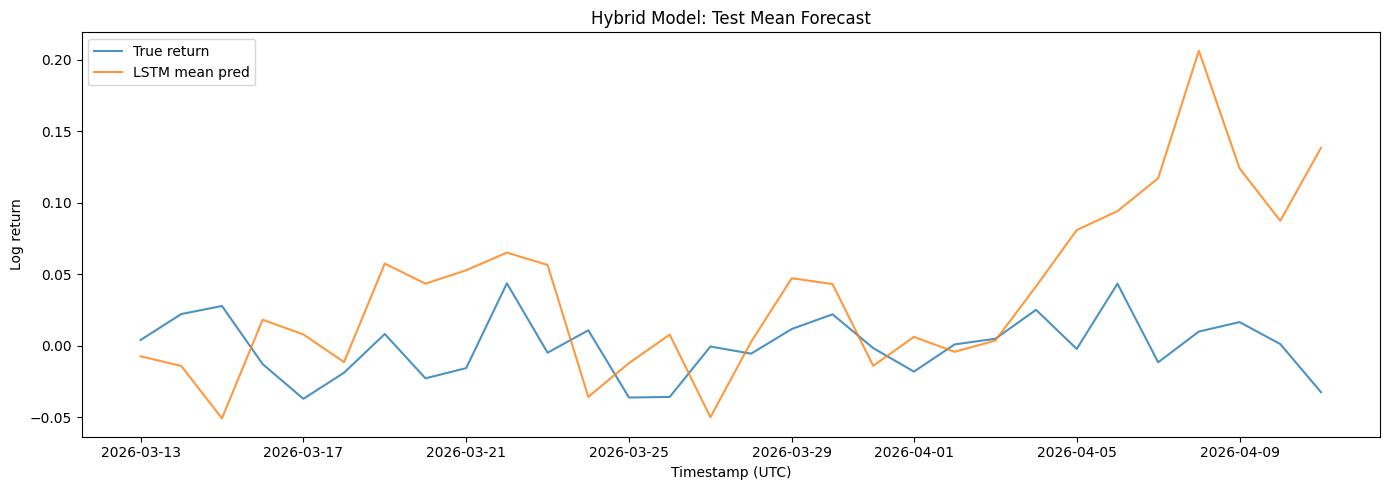

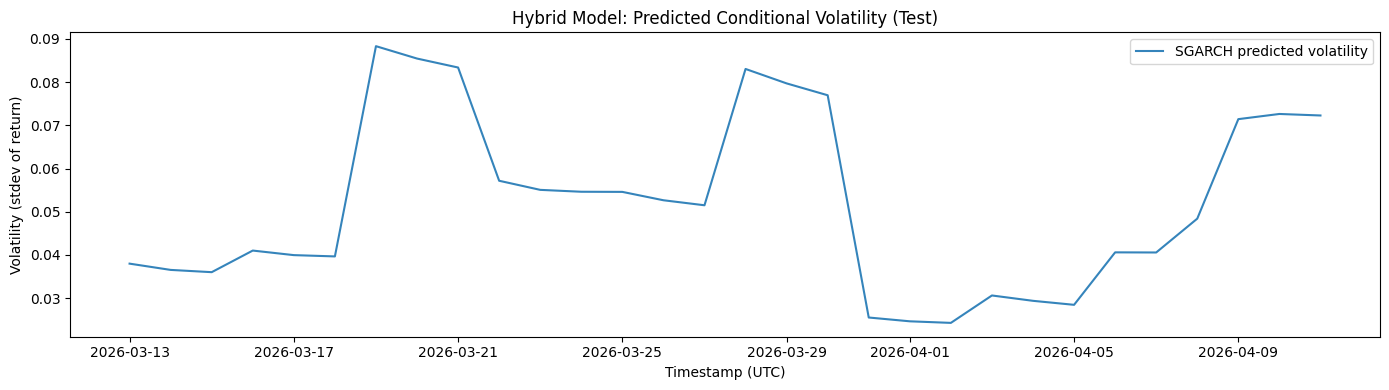

{'best_params': {'seq_len': 7,
  'lstm_units': 32,
  'dropout': 0.2,
  'learning_rate': 0.001,
  'batch_size': 64},
 'validation_mean_metrics': {'mean_rmse': 0.05666302243506327,
  'mean_mae': 0.05091113969683647,
  'qlike': -4.354825929009509,
  'var_mse': 7.402340369059454e-05,
  'direction_acc': 0.4333333333333334},
 'test_mean_metrics': {'mean_rmse': 0.05853418786611333,
  'mean_mae': 0.05292063700035214,
  'qlike': -4.0351144290902905,
  'var_mse': 7.939569319137901e-05,
  'direction_acc': 0.4666666666666666}}

In [ ]:
# Diagnostic plots: mean forecast and SGARCH volatility
plot_df = test_preds_df.copy()
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)
plot_df = plot_df.sort_values(TIMESTAMP_COL)

plt.figure(figsize=(14, 5))
plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='True return', alpha=0.8)
plt.plot(plot_df[TIMESTAMP_COL], plot_df['lstm_mean_pred'], label='LSTM mean pred', alpha=0.8)
plt.title('Hybrid Model: Test Mean Forecast')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Log return')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(plot_df[TIMESTAMP_COL], plot_df['sgarch_vol_pred'], label='SGARCH predicted volatility', alpha=0.9)
plt.title('Hybrid Model: Predicted Conditional Volatility (Test)')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Volatility (stdev of return)')
plt.legend()
plt.tight_layout()
plt.show()

summary = {
    'best_params': best_params,
    'validation_mean_metrics': val_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_dict(),
    'test_mean_metrics': test_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_dict(),
}

with (ARTIFACTS_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

summary